In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
train_dir = "E:\\Pyhton code\\Data Sets\\archive\\melanoma_cancer_dataset\\train"
test_dir = "E:\\Pyhton code\\Data Sets\\archive\\melanoma_cancer_dataset\\test"

In [4]:
import os
print(os.listdir(train_dir))

['benign', 'malignant']


In [5]:
for cls in os.listdir(train_dir):

    path = os.path.join(train_dir, cls)

    print(cls, len(os.listdir(path)))

benign 5000
malignant 4605


In [6]:
for cls in os.listdir(test_dir):
    
    path = os.path.join(test_dir, cls)

    print(cls, len(os.listdir(path)))

benign 500
malignant 500


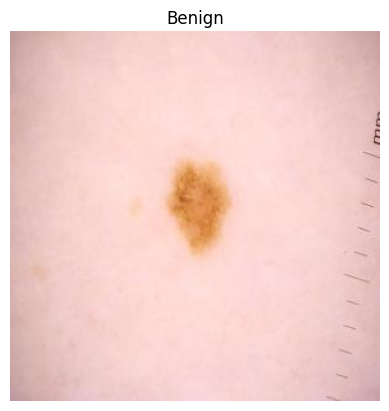

In [7]:
#visualize images
benign_path = os.path.join(train_dir, "benign")

image_name = os.listdir(benign_path)[0]

image_path = os.path.join(benign_path, image_name)

img = plt.imread(image_path)

plt.imshow(img)

plt.title("Benign")

plt.axis("off")

plt.show()

In [8]:
print(img.shape)

(300, 300, 3)


In [9]:
# ===================================
# Image Transform
# ===================================
import torchvision.transforms as transforms
transform = transforms.Compose([

    transforms.Resize((64, 64)),

    transforms.ToTensor()

])

In [10]:
# ===================================
# Training Dataset
# ===================================

from torchvision import datasets
train_dataset = datasets.ImageFolder(

    root=train_dir,

    transform=transform

)

# ===================================
# Testing Dataset
# ===================================

test_dataset = datasets.ImageFolder(

    root=test_dir,

    transform=transform

)

In [11]:
print(train_dataset)

Dataset ImageFolder
    Number of datapoints: 9605
    Root location: E:\Pyhton code\Data Sets\archive\melanoma_cancer_dataset\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [12]:
print(train_dataset.classes)

['benign', 'malignant']


In [13]:
print(train_dataset.class_to_idx)

{'benign': 0, 'malignant': 1}


In [14]:
print(len(train_dataset))

print(len(test_dataset))

9605
1000


In [15]:
image, label = train_dataset[0]

print(image.shape)

print(label)

torch.Size([3, 64, 64])
0


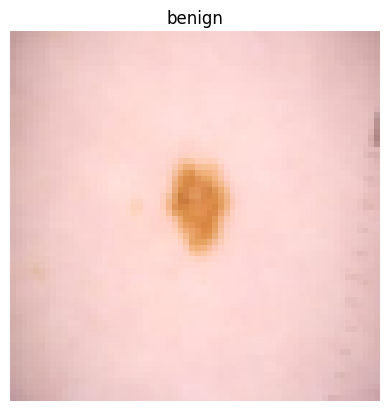

In [16]:
plt.imshow(image.permute(1, 2, 0))

plt.title(train_dataset.classes[label])

plt.axis("off")

plt.show()

In [17]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [18]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = r"E:\Pyhton code\Data Sets\archive\melanoma_cancer_dataset\train"
test_dir = r"E:\Pyhton code\Data Sets\archive\melanoma_cancer_dataset\test"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [19]:
import torch.nn as nn

class ANN(nn.Module):

    def __init__(self):

        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(

            nn.Linear(64 * 64 * 3, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 2)

        )

    def forward(self, x):

        x = self.flatten(x)

        x = self.network(x)

        return x

In [20]:
model = ANN().to(device)

print(model)

ANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=12288, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [21]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [22]:
epochs = 10

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(epochs):

    ##############################
    # Training
    ##############################

    model.train()

    train_loss = 0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    train_loss /= len(train_loader)

    train_acc = 100 * correct / total

    ##############################
    # Validation
    ##############################

    model.eval()

    val_loss = 0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()

            total += labels.size(0)

    val_loss /= len(test_loader)

    val_acc = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/10] | Train Loss: 0.4689 | Train Acc: 76.59% | Val Loss: 0.3435 | Val Acc: 86.40%
Epoch [2/10] | Train Loss: 0.3742 | Train Acc: 82.21% | Val Loss: 0.6190 | Val Acc: 63.80%
Epoch [3/10] | Train Loss: 0.3439 | Train Acc: 84.19% | Val Loss: 0.3596 | Val Acc: 83.60%
Epoch [4/10] | Train Loss: 0.3301 | Train Acc: 85.26% | Val Loss: 0.3004 | Val Acc: 87.80%
Epoch [5/10] | Train Loss: 0.3204 | Train Acc: 85.54% | Val Loss: 0.2990 | Val Acc: 86.40%
Epoch [6/10] | Train Loss: 0.3157 | Train Acc: 85.85% | Val Loss: 0.2947 | Val Acc: 87.60%
Epoch [7/10] | Train Loss: 0.2949 | Train Acc: 87.56% | Val Loss: 0.3926 | Val Acc: 86.50%
Epoch [8/10] | Train Loss: 0.2925 | Train Acc: 87.25% | Val Loss: 0.2879 | Val Acc: 87.90%
Epoch [9/10] | Train Loss: 0.2897 | Train Acc: 87.42% | Val Loss: 0.3047 | Val Acc: 88.10%
Epoch [10/10] | Train Loss: 0.2903 | Train Acc: 87.40% | Val Loss: 0.2904 | Val Acc: 87.90%


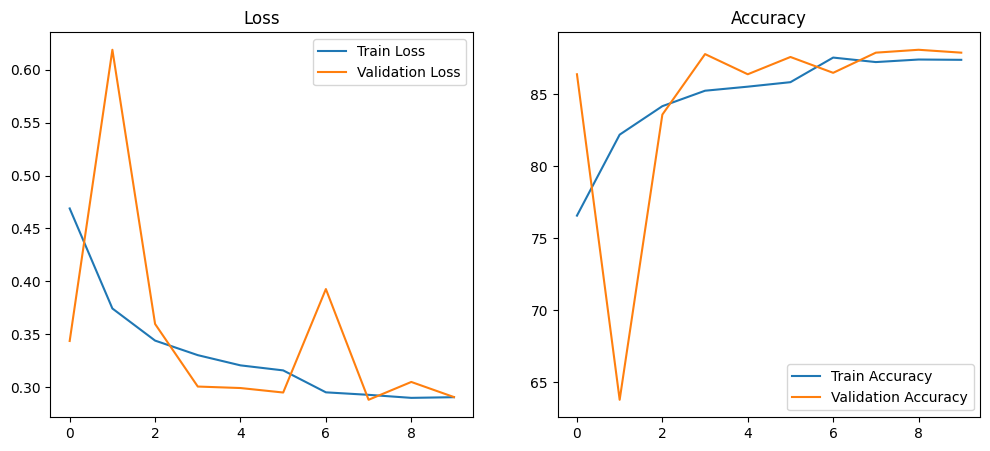

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)

plt.plot(train_accs,label="Train Accuracy")
plt.plot(val_accs,label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.show()

In [24]:
from sklearn.metrics import accuracy_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_true.extend(labels.numpy())

        y_pred.extend(predicted.cpu().numpy())

accuracy = accuracy_score(y_true,y_pred)

print(f"Test Accuracy : {accuracy*100:.2f}%")

Test Accuracy : 87.90%


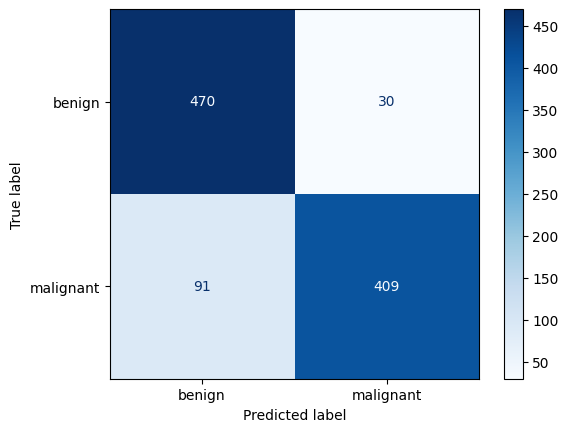

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(cmap="Blues")

plt.show()

In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes
    )
)

              precision    recall  f1-score   support

      benign       0.84      0.94      0.89       500
   malignant       0.93      0.82      0.87       500

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



# Building cnn model

In [27]:
from PIL import Image
import os

sizes = []

for cls in ["benign", "malignant"]:
    folder = os.path.join(train_dir, cls)

    for img_name in os.listdir(folder):
        img = Image.open(os.path.join(folder, img_name))
        sizes.append(img.size)

print("Unique image sizes:", len(set(sizes)))
print("First 10 sizes:", list(set(sizes))[:10])

Unique image sizes: 1
First 10 sizes: [(300, 300)]


In [28]:
import torchvision.transforms as transforms
transform = transforms.Compose([
    transforms.ToTensor()
])

In [29]:
from torchvision import datasets
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

In [30]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [31]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 300, 300])
torch.Size([16])


In [32]:
#model 
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        # ==========================
        # Feature Extractor
        # ==========================

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            # Block 4
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            # Global Average Pooling
            nn.AdaptiveAvgPool2d((1, 1))

        )

        # ==========================
        # Classifier
        # ==========================

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256, 128),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 2)

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [33]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [34]:
model = CNN().to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [35]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([16, 2])


In [36]:
x = images

print(f"Input                : {x.shape}")

for i, layer in enumerate(model.features):

    x = layer(x)

    print(f"Layer {i+1:<2} {layer.__class__.__name__:<20} {x.shape}")

Input                : torch.Size([16, 3, 300, 300])
Layer 1  Conv2d               torch.Size([16, 32, 300, 300])
Layer 2  ReLU                 torch.Size([16, 32, 300, 300])
Layer 3  MaxPool2d            torch.Size([16, 32, 150, 150])
Layer 4  Conv2d               torch.Size([16, 64, 150, 150])
Layer 5  ReLU                 torch.Size([16, 64, 150, 150])
Layer 6  MaxPool2d            torch.Size([16, 64, 75, 75])
Layer 7  Conv2d               torch.Size([16, 128, 75, 75])
Layer 8  ReLU                 torch.Size([16, 128, 75, 75])
Layer 9  MaxPool2d            torch.Size([16, 128, 37, 37])
Layer 10 Conv2d               torch.Size([16, 256, 37, 37])
Layer 11 ReLU                 torch.Size([16, 256, 37, 37])
Layer 12 AdaptiveAvgPool2d    torch.Size([16, 256, 1, 1])


In [37]:
feature_maps = []

x = images

for layer in model.features:

    x = layer(x)

    if isinstance(layer, nn.Conv2d):

        feature_maps.append(x)

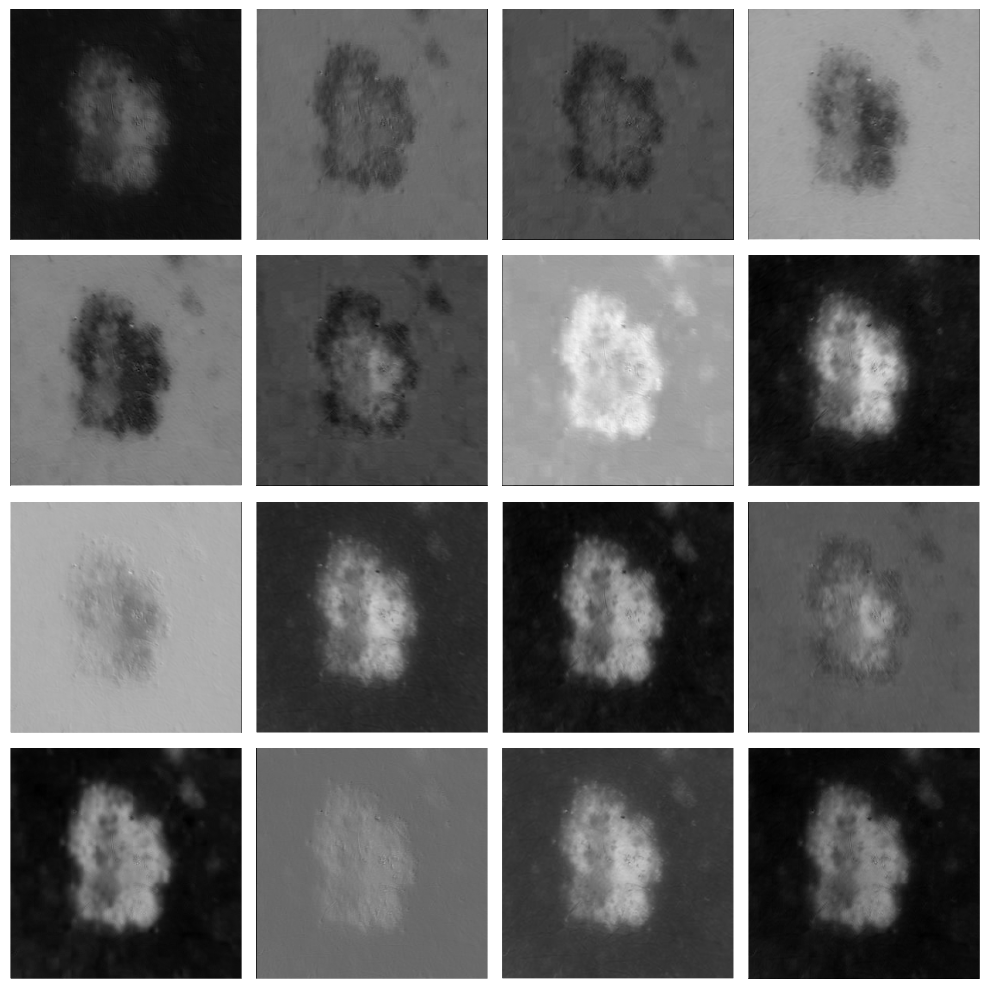

In [38]:
import matplotlib.pyplot as plt

layer_no = 0        # 0,1,2,3
num_maps = 16         # show first 16 feature maps

fm = feature_maps[layer_no][0].detach().cpu()

fig, axes = plt.subplots(4,4,figsize=(10,10))

for i, ax in enumerate(axes.flat):

    ax.imshow(fm[i], cmap="gray")

    ax.axis("off")

plt.tight_layout()

plt.show()

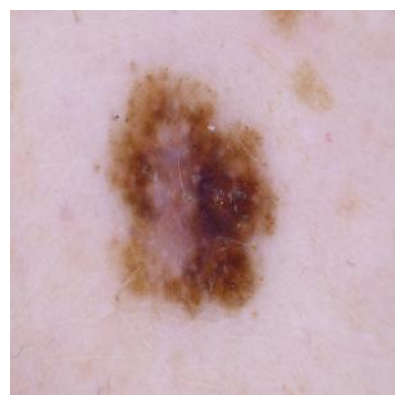

In [39]:
plt.figure(figsize=(5,5))

img = images[0].permute(1,2,0).cpu()

plt.imshow(img)

plt.axis("off")

plt.show()

In [40]:
weights = model.features[0].weight.detach().cpu()

print(weights.shape)

torch.Size([32, 3, 3, 3])


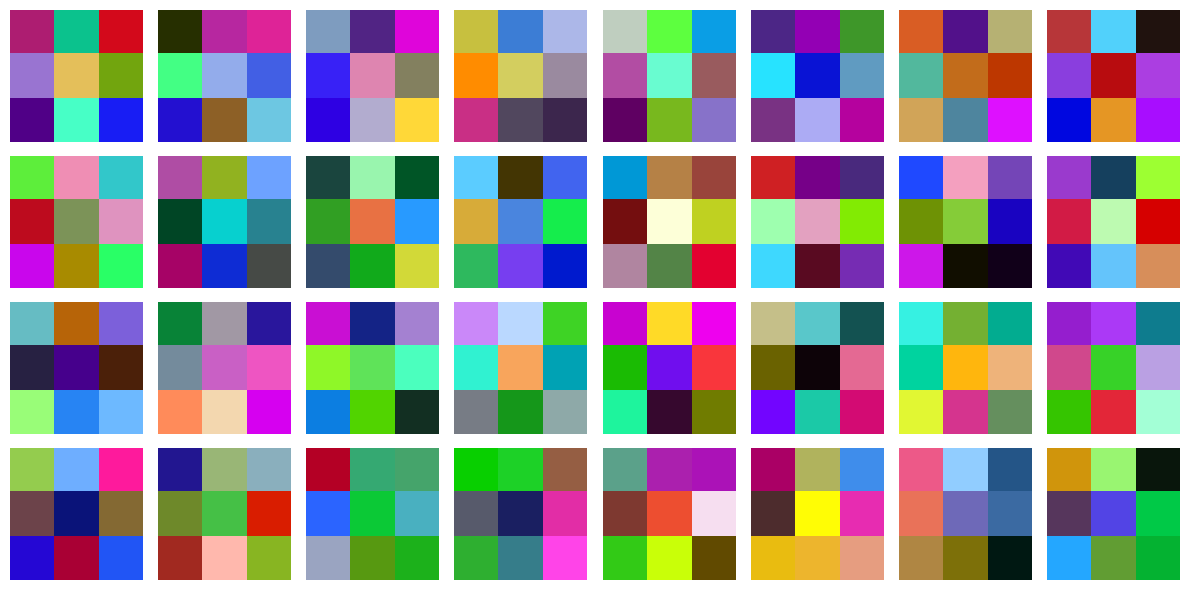

In [41]:
fig, axes = plt.subplots(4,8,figsize=(12,6))

for i, ax in enumerate(axes.flat):

    filt = weights[i]

    filt = (filt - filt.min()) / (filt.max() - filt.min())

    filt = filt.permute(1,2,0)

    ax.imshow(filt)

    ax.axis("off")

plt.tight_layout()

plt.show()

In [42]:
initial_filters = model.features[0].weight.detach().cpu().clone()

In [43]:
trained_filters = model.features[0].weight.detach().cpu()

In [44]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [45]:
epochs = 15

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(epochs):

    ############################
    # Training
    ############################

    model.train()

    train_loss = 0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    train_loss /= len(train_loader)

    train_acc = 100 * correct / total

    ############################
    # Validation
    ############################

    model.eval()

    val_loss = 0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            correct += (predicted == labels).sum().item()

            total += labels.size(0)

    val_loss /= len(test_loader)

    val_acc = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1:02d}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [01/15] | Train Loss: 0.4772 | Train Acc: 78.42% | Val Loss: 0.3574 | Val Acc: 83.60%
Epoch [02/15] | Train Loss: 0.4357 | Train Acc: 80.85% | Val Loss: 0.3703 | Val Acc: 82.90%
Epoch [03/15] | Train Loss: 0.4001 | Train Acc: 82.67% | Val Loss: 0.3692 | Val Acc: 84.80%
Epoch [04/15] | Train Loss: 0.3547 | Train Acc: 85.00% | Val Loss: 0.2913 | Val Acc: 86.60%
Epoch [05/15] | Train Loss: 0.3077 | Train Acc: 86.78% | Val Loss: 0.2739 | Val Acc: 87.90%
Epoch [06/15] | Train Loss: 0.2942 | Train Acc: 87.55% | Val Loss: 0.2835 | Val Acc: 88.10%
Epoch [07/15] | Train Loss: 0.2794 | Train Acc: 88.04% | Val Loss: 0.2540 | Val Acc: 90.00%
Epoch [08/15] | Train Loss: 0.2700 | Train Acc: 88.83% | Val Loss: 0.2706 | Val Acc: 89.00%
Epoch [09/15] | Train Loss: 0.2607 | Train Acc: 89.20% | Val Loss: 0.2538 | Val Acc: 90.20%
Epoch [10/15] | Train Loss: 0.2530 | Train Acc: 89.25% | Val Loss: 0.2594 | Val Acc: 90.00%
Epoch [11/15] | Train Loss: 0.2364 | Train Acc: 90.20% | Val Loss: 0.2555 | Val 

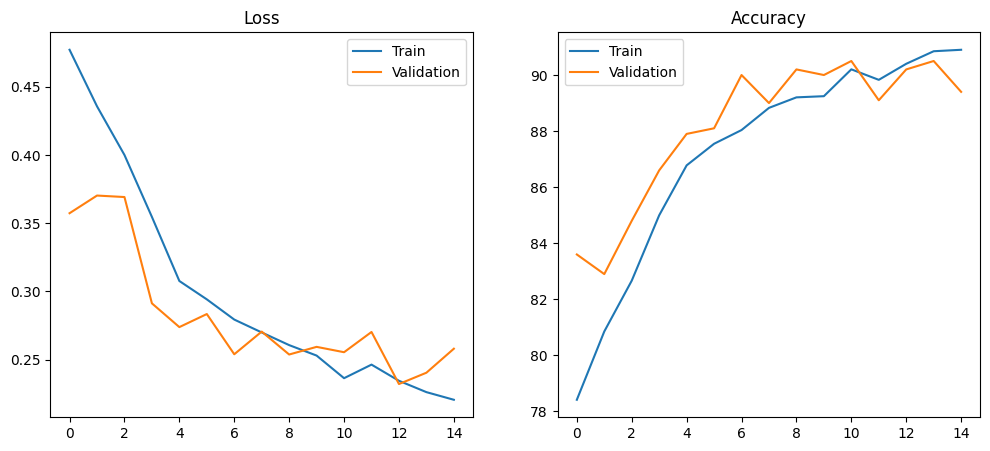

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.title("Loss")

plt.legend()

plt.subplot(1,2,2)

plt.plot(train_accs,label="Train")
plt.plot(val_accs,label="Validation")

plt.title("Accuracy")

plt.legend()

plt.show()

In [47]:
from sklearn.metrics import accuracy_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_true.extend(labels.numpy())

        y_pred.extend(predicted.cpu().numpy())

accuracy = accuracy_score(y_true,y_pred)

print(f"Test Accuracy : {accuracy*100:.2f}%")

Test Accuracy : 89.40%


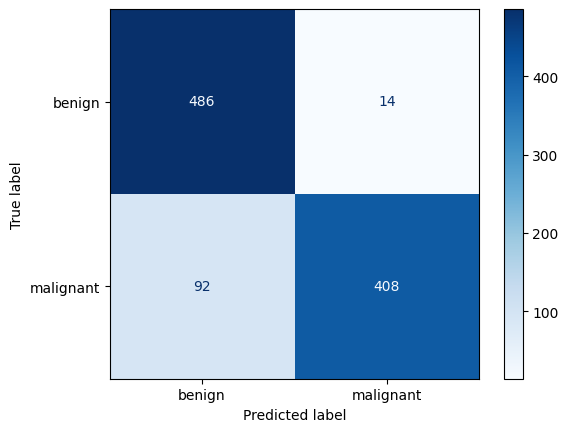

In [48]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(cmap="Blues")

plt.show()

In [49]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes
    )
)

              precision    recall  f1-score   support

      benign       0.84      0.97      0.90       500
   malignant       0.97      0.82      0.89       500

    accuracy                           0.89      1000
   macro avg       0.90      0.89      0.89      1000
weighted avg       0.90      0.89      0.89      1000



# Using transfer learning

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import numpy as np

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [52]:
# iamgenet transform
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [53]:
train_path = r"E:\Pyhton code\Data Sets\archive\melanoma_cancer_dataset\train"
test_path  = r"E:\Pyhton code\Data Sets\archive\melanoma_cancer_dataset\test"

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=test_transform
)

print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset))
print("Test :", len(test_dataset))

Classes: ['benign', 'malignant']
Train: 9605
Test : 1000


In [54]:
# data loader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [55]:
vgg16 = models.vgg16(
    weights=models.VGG16_Weights.DEFAULT
)

vgg16 = vgg16.to(device)

In [56]:
# freeze pretrained layers
for param in vgg16.features.parameters():
    param.requires_grad = False

In [57]:
# replace VGG16 classifier
vgg16.classifier[6] = nn.Linear(
    vgg16.classifier[6].in_features,
    2
)

vgg16 = vgg16.to(device)

In [58]:
print(vgg16.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)


In [59]:
# count trainable parameter
trainable_params = sum(
    p.numel()
    for p in vgg16.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in vgg16.parameters()
)

print("Total Parameters    :", total_params)
print("Trainable Parameters:", trainable_params)

Total Parameters    : 134268738
Trainable Parameters: 119554050


In [60]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16.parameters()),
    lr=1e-3
)

In [61]:
print("Model device:", next(vgg16.parameters()).device)

images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

images = images.to(device)
labels = labels.to(device)

outputs = vgg16(images)

print("Outputs:", outputs.shape)

Model device: cuda:0
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])
Outputs: torch.Size([32, 2])


In [62]:
# epochs
epochs = 10

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(epochs):

    # ==========================
    # Training
    # ==========================

    vgg16.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = vgg16(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # ==========================
    # Validation
    # ==========================

    vgg16.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = vgg16(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(test_loader)
    val_acc = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1:02d}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [01/10] | Train Loss: 0.3933 | Train Acc: 87.05% | Val Loss: 0.3798 | Val Acc: 88.10%
Epoch [02/10] | Train Loss: 0.3733 | Train Acc: 90.29% | Val Loss: 0.3807 | Val Acc: 89.90%
Epoch [03/10] | Train Loss: 0.2564 | Train Acc: 92.80% | Val Loss: 0.2981 | Val Acc: 90.50%
Epoch [04/10] | Train Loss: 0.2146 | Train Acc: 94.27% | Val Loss: 0.2836 | Val Acc: 91.40%
Epoch [05/10] | Train Loss: 0.1830 | Train Acc: 94.87% | Val Loss: 0.5048 | Val Acc: 91.50%
Epoch [06/10] | Train Loss: 0.1696 | Train Acc: 95.70% | Val Loss: 0.5650 | Val Acc: 92.20%
Epoch [07/10] | Train Loss: 0.1491 | Train Acc: 95.91% | Val Loss: 0.4248 | Val Acc: 91.00%
Epoch [08/10] | Train Loss: 0.1342 | Train Acc: 96.61% | Val Loss: 0.7255 | Val Acc: 90.90%
Epoch [09/10] | Train Loss: 0.1388 | Train Acc: 96.63% | Val Loss: 0.7604 | Val Acc: 91.10%
Epoch [10/10] | Train Loss: 0.1602 | Train Acc: 96.99% | Val Loss: 0.9733 | Val Acc: 91.80%


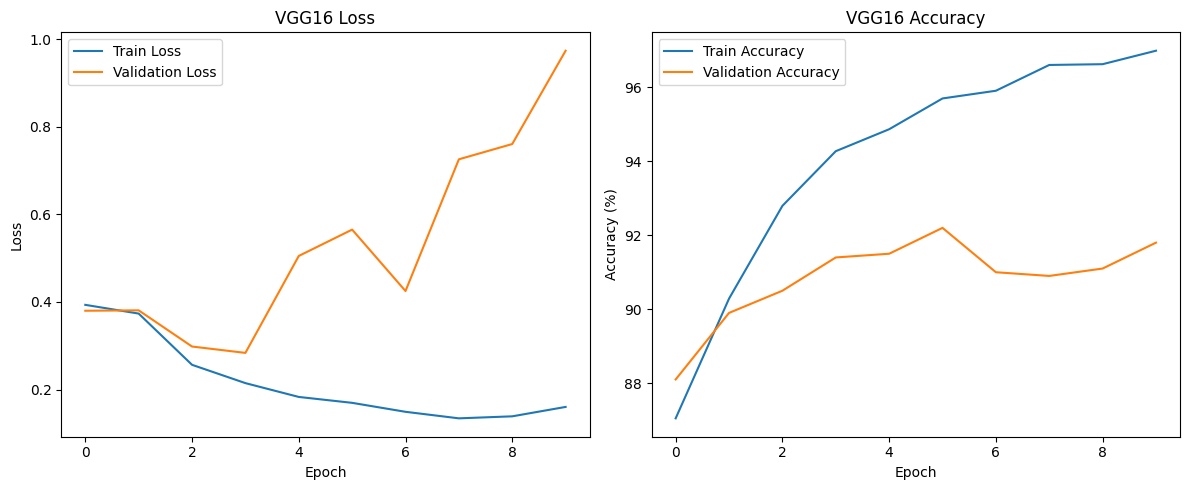

In [63]:
#plot training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Loss")

plt.legend()


plt.subplot(1, 2, 2)

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("VGG16 Accuracy")

plt.legend()

plt.tight_layout()
plt.show()

In [64]:
# test evaluation
vgg16.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)

        outputs = vgg16(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())


test_accuracy = accuracy_score(y_true, y_pred)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 91.80%


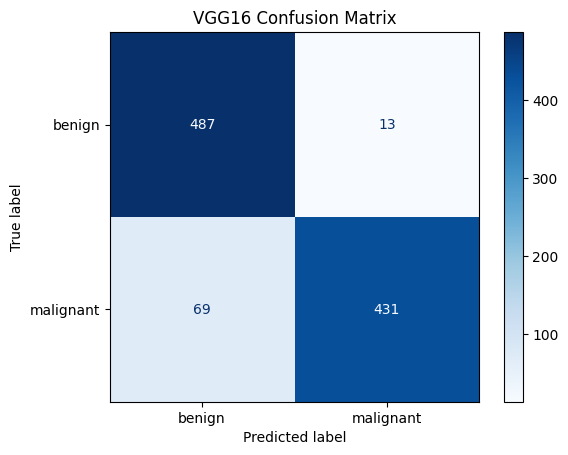

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot(cmap="Blues")

plt.title("VGG16 Confusion Matrix")
plt.show()

In [66]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_dataset.classes
    )
)

              precision    recall  f1-score   support

      benign       0.88      0.97      0.92       500
   malignant       0.97      0.86      0.91       500

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [67]:
torch.save(
    vgg16.state_dict(),
    "vgg16_frozen_classifier.pth"
)

# Fine tune VGG16 model for skin cancer classification

In [68]:
train_path = r"E:\Pyhton code\Data Sets\archive\melanoma_cancer_dataset\train"
test_path  = r"E:\Pyhton code\Data Sets\archive\melanoma_cancer_dataset\test"

In [69]:
# transform
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [70]:
# load dataset
full_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=val_test_transform
)

print("Classes:", full_dataset.classes)
print("Training pool:", len(full_dataset))
print("Test:", len(test_dataset))

Classes: ['benign', 'malignant']
Training pool: 9605
Test: 1000


In [71]:
# train/validation split
from torch.utils.data import DataLoader, random_split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 7684
Validation: 1921
Test: 1000


In [72]:
# separate validation transform
val_dataset.dataset = datasets.ImageFolder(
    root=train_path,
    transform=val_test_transform
)

In [73]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 241
Val batches: 61
Test batches: 32


In [74]:
vgg16 = models.vgg16(
    weights=models.VGG16_Weights.DEFAULT
)

In [75]:
# freeze early layers + fine-tune last block
for param in vgg16.features.parameters():
    param.requires_grad = False

# Fine-tune last convolutional block
for param in vgg16.features[24:].parameters():
    param.requires_grad = True

In [76]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(4096, 1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(1024, 2)
)

vgg16 = vgg16.to(device)

print(vgg16.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=1024, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=1024, out_features=2, bias=True)
)


In [77]:
total_params = sum(
    p.numel()
    for p in vgg16.parameters()
)

trainable_params = sum(
    p.numel()
    for p in vgg16.parameters()
    if p.requires_grad
)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 121,676,610
Trainable parameters : 114,041,346


In [78]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, vgg16.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

In [79]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

In [80]:
import copy
epochs = 20

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0.0
best_model_state = None

patience = 5
epochs_without_improvement = 0

for epoch in range(epochs):

    # ==========================
    # TRAIN
    # ==========================

    vgg16.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = vgg16(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # ==========================
    # VALIDATION
    # ==========================

    vgg16.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = vgg16(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            predicted = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # LR scheduler
    scheduler.step(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    # ==========================
    # BEST MODEL
    # ==========================

    if val_acc > best_val_acc:

        best_val_acc = val_acc
        best_model_state = copy.deepcopy(vgg16.state_dict())

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch+1:02d}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.2e}"
    )

    # ==========================
    # EARLY STOPPING
    # ==========================

    if epochs_without_improvement >= patience:

        print("\nEarly stopping triggered.")
        break

Epoch [01/20] | Train Loss: 0.3214 | Train Acc: 86.57% | Val Loss: 0.2719 | Val Acc: 88.76% | LR: 1.00e-05
Epoch [02/20] | Train Loss: 0.2279 | Train Acc: 91.03% | Val Loss: 0.2517 | Val Acc: 89.90% | LR: 1.00e-05
Epoch [03/20] | Train Loss: 0.2072 | Train Acc: 91.63% | Val Loss: 0.2318 | Val Acc: 91.20% | LR: 1.00e-05
Epoch [04/20] | Train Loss: 0.1940 | Train Acc: 92.36% | Val Loss: 0.2174 | Val Acc: 91.93% | LR: 1.00e-05
Epoch [05/20] | Train Loss: 0.1863 | Train Acc: 92.62% | Val Loss: 0.2104 | Val Acc: 91.83% | LR: 1.00e-05
Epoch [06/20] | Train Loss: 0.1724 | Train Acc: 93.18% | Val Loss: 0.2150 | Val Acc: 91.72% | LR: 1.00e-05
Epoch [07/20] | Train Loss: 0.1644 | Train Acc: 93.51% | Val Loss: 0.2283 | Val Acc: 91.88% | LR: 5.00e-06
Epoch [08/20] | Train Loss: 0.1537 | Train Acc: 93.86% | Val Loss: 0.2192 | Val Acc: 92.35% | LR: 5.00e-06
Epoch [09/20] | Train Loss: 0.1452 | Train Acc: 94.29% | Val Loss: 0.2098 | Val Acc: 92.66% | LR: 5.00e-06
Epoch [10/20] | Train Loss: 0.1506 | 

In [81]:
vgg16.load_state_dict(best_model_state)

vgg16 = vgg16.to(device)
vgg16.eval()

print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

Best Validation Accuracy: 92.66%


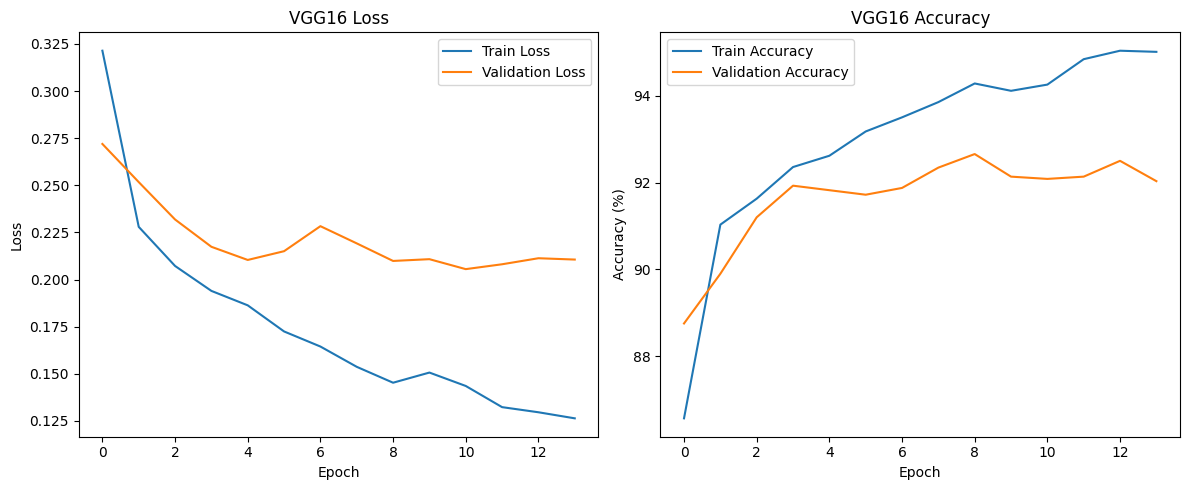

In [82]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Loss")

plt.legend()


plt.subplot(1, 2, 2)

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("VGG16 Accuracy")

plt.legend()

plt.tight_layout()
plt.show()

In [83]:
vgg16.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)

        outputs = vgg16(images)

        predicted = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

In [84]:
test_accuracy = accuracy_score(y_true, y_pred)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Final Test Accuracy: 91.40%


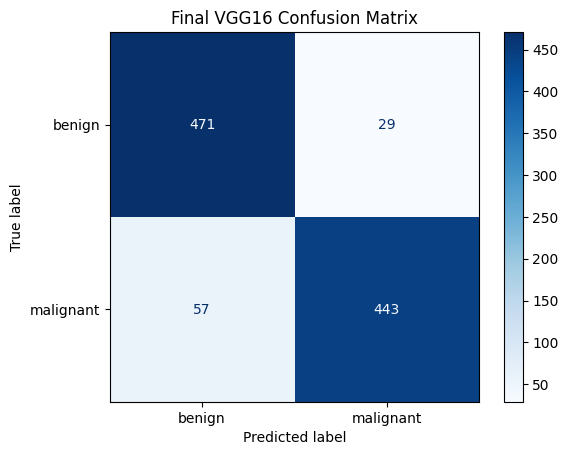

In [85]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot(cmap="Blues")

plt.title("Final VGG16 Confusion Matrix")
plt.show()

In [86]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_dataset.classes,
        digits=4
    )
)

              precision    recall  f1-score   support

      benign     0.8920    0.9420    0.9163       500
   malignant     0.9386    0.8860    0.9115       500

    accuracy                         0.9140      1000
   macro avg     0.9153    0.9140    0.9139      1000
weighted avg     0.9153    0.9140    0.9139      1000



In [87]:
report = classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.classes,
    output_dict=True
)

malignant_recall = report["malignant"]["recall"]
malignant_precision = report["malignant"]["precision"]
malignant_f1 = report["malignant"]["f1-score"]

print(f"Malignant Precision : {malignant_precision:.4f}")
print(f"Malignant Recall    : {malignant_recall:.4f}")
print(f"Malignant F1        : {malignant_f1:.4f}")

Malignant Precision : 0.9386
Malignant Recall    : 0.8860
Malignant F1        : 0.9115


In [88]:
torch.save(
    vgg16.state_dict(),
    "vgg16_melanoma_final.pth"
)

print("Model saved.")

Model saved.


# Melanoma Cancer Classification — Project Report

## Dataset

* **Task:** Binary skin-cancer image classification
* **Classes:** `benign`, `malignant`
* **Training images:** 9,605

  * Benign: 5,000
  * Malignant: 4,605
* **Test images:** 1,000

  * Benign: 500
  * Malignant: 500
* **Original image size:** `300 × 300`
* **Framework:** PyTorch
* **GPU:** NVIDIA RTX 2050

## Models Implemented

### 1. ANN — Baseline

Images were resized to `64 × 64` and flattened:

```text
[3, 64, 64] → [12288]
```

The ANN achieved:

* **Test Accuracy:** 88.20%
* Malignant Precision: 0.92
* Malignant Recall: 0.83
* Malignant F1: 0.88

ANN was used as a **baseline** to compare against CNN-based approaches.

---

### 2. Custom CNN

Used convolutional layers to learn spatial features:

```text
Image
 ↓
Convolution
 ↓
Activation
 ↓
Pooling
 ↓
Convolution
 ↓
Activation
 ↓
Pooling
 ↓
Classification
```

Feature maps were also visualized to understand what different CNN layers learn.

Result:

* **Test Accuracy:** 91.50%
* Malignant Precision: 0.93
* Malignant Recall: 0.89
* Malignant F1: 0.91

CNN improved significantly over the ANN baseline.

---

### 3. VGG16 — Transfer Learning

Used pretrained **VGG16** and replaced the final classifier for the two classes.

Input:

```text
[32, 3, 224, 224]
```

Output:

```text
[32, 2]
```

Result:

* **Test Accuracy:** 91.70%
* Malignant Precision: 0.98
* Malignant Recall: 0.85
* Malignant F1: 0.91

---

### 4. VGG16 — Fine-Tuning

Unfroze and fine-tuned the final layers of VGG16.

Result:

* **Test Accuracy:** **92.00%**
* Malignant Precision: 0.97
* Malignant Recall: 0.87
* Malignant F1: 0.92

This became the **best model so far**.

---

### 5. VGG16 + Regularization & Augmentation

Added techniques such as:

* Data augmentation
* Dropout
* Regularization
* Fine-tuning

Result:

* Best Validation Accuracy: **92.66%**
* Test Accuracy: 91.40%
* Malignant Precision: 0.9386
* Malignant Recall: 0.8860
* Malignant F1: 0.9115

This version did **not** improve the test accuracy over the simpler fine-tuned VGG16.

---

## Current Results

```text
ANN                         → 88.20%
Custom CNN                  → 91.50%
VGG16 Transfer Learning     → 91.70%
VGG16 Fine-Tuning           → 92.00%  ← Best
VGG16 + Augmentation        → 91.40%
```

## Current Conclusion

CNN significantly outperformed the ANN baseline because it preserves spatial information and learns local visual features.

Transfer learning with VGG16 further improved performance, with **fine-tuned VGG16 currently being the best model at 92.00% test accuracy**.

### Next

```text
ResNet50 Transfer Learning
        ↓
ResNet50 Fine-Tuning
        ↓
Compare with VGG16
        ↓
Select Final Model
```
